## **Analisis Exploratorio**
### **Desigualdad Educativa en Chile:** Análisis de Resultados PAES por Tipo de Establecimiento

#### **Nombres:** Lucas Chicao - Ninoska Cid - Isidora Gomez

#### **Curso**: IMT-2200 - Introduccion a la Ciencias de Datos

___
### **Contexto del proyecto:** 
La PAES es la prueba que miles de estudiantes chilenos rinden para acceder a la universidad, pero es un hecho que no todos cuentan con las mismas oportunidades educativas, ya que estas dependen del tipo de colegio en el que estudiaron.

En este proyecto, nos proponemos investigar si efectivamente hay diferencias en los puntajes de la PAES entre estudiantes de colegios públicos, subvencionados y privados, y también medir la magnitud de esas posibles diferencias.


### **Preguntas a responder:**
-¿Hay diferencias en los puntajes entre colegios públicos, subvencionados y privados?

-¿Qué tipo de colegio tiene mejores resultados en promedio?

-¿Qué tan grande es la brecha entre estos grupos?

-¿Existe correlación entre el tipo de establecimiento y las probabilidades de acceso a universidades tradicionales?

-¿Los resultados confirman las desigualdades educativas documentadas en otros estudios?

-...

### **Datos a usar:**
Los datos que usaremos en nuestro proyecto seran principalmente de base de datos de:

-DEMRE

-chiquillos si les parece aqui hay una base de datos para poder usar, si lo usamos eliminen este mensajito: https://www.kaggle.com/datasets/daniellopez01/admisionuescl

### **Analisis Exploratorio:**
En las siguientes lineas exploraremos los datos que ya obtuvimos y revisaremos como vamos en relacion con datos.
 

In [2]:
#LIBRERIAS A USAR
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
#...

# Analisis Exploratorio de la base de datos del DEMRE (2023 - 2025)

En este JupyterNotebook vamos  a aplicarle EDA a los archivos clasificados como Matricula de 2023 a 2025 de la Base de datos del DEMRE 

In [3]:
#CARGAR DATOS Y DF

base_path = os.path.dirname(os.getcwd())  # Esto sube un nivel desde 'Análisis Exploratorio'

file_path_23 = os.path.join(base_path, 'DEMRE_bdd', '2023','Matricula','Matricula_Admisión2023','ArchivoMatr_Adm2023.csv')
file_path_24 = os.path.join(base_path, 'DEMRE_bdd', '2024','Matricula','Matricula_Admisión2024','ArchivoMatr_Adm2024.csv')
file_path_25 = os.path.join(base_path, 'DEMRE_bdd', '2025','Matricula','Matricula_Admisión2025','ArchivoMatr_Adm2025.csv')

df_2023_matricula = pd.read_csv(file_path_23, sep=';')
df_2024_matricula = pd.read_csv(file_path_24, sep=';')
df_2025_matricula = pd.read_csv(file_path_25, sep=';')
# los uno en un solo df
df_matriculas = pd.concat([df_2023_matricula, df_2024_matricula, df_2025_matricula], ignore_index=True)
df_matriculas

,ID_aux,CODIGO_UNIV,CODIGO,VIA,PREFERENCIA,PTJE_POND,TIPO_MATRICULA
0,id_267832678788,30,30055,1,1,513.6,1
1,id_016130170616,45,45021,1,1,565.85,1
2,id_514305173430,56,56524,1,3,724.7,1
3,id_042500470254,47,47303,1,1,697.6,1
4,id_699806974987,45,45009,1,2,722.0,1
...,...,...,...,...,...,...,...
354168,id_616564148517,34,34024,1,1,"796,7",1
354169,id_626669249595,16,16092,1,3,"847,4",1
354170,id_626667240384,17,17079,1,1,567,1
354171,id_8198831341292,55,55062,1,3,"630,75",1


In [4]:
#EXPLORACION
print(f'Columnas : {df_matriculas.columns}')
print('-----------')
print(f'Filas : {df_matriculas.shape[0]}, Columnas : {df_matriculas.shape[1]}') #Filas, Columnas
print('-----------\n')
print(df_matriculas.info())
print('-----------')

Columnas : Index(['ID_aux', 'CODIGO_UNIV', 'CODIGO', 'VIA', 'PREFERENCIA', 'PTJE_POND',
       'TIPO_MATRICULA'],
      dtype='object')
-----------
Filas : 354173, Columnas : 7
-----------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354173 entries, 0 to 354172
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   ID_aux          354173 non-null  object
 1   CODIGO_UNIV     354173 non-null  int64 
 2   CODIGO          354173 non-null  int64 
 3   VIA             354173 non-null  int64 
 4   PREFERENCIA     354173 non-null  int64 
 5   PTJE_POND       354173 non-null  object
 6   TIPO_MATRICULA  354173 non-null  int64 
dtypes: int64(5), object(2)
memory usage: 18.9+ MB
None
-----------


## Limpieza de los datos

In [64]:
#LIMPIEZA DE DATOS
'''
Columnas : Index(['ID_aux', 'CODIGO_UNIV', 'CODIGO', 'VIA', 'PREFERENCIA', 'PTJE_POND',
       'TIPO_MATRICULA'],
      dtype='object')
'''

columnas_criticas = ['ID_aux', 'PTJE_POND']
# elegimos estas columnas pq:
# ID_aux -> si no hay id unico de un postulante, entonces no hay estudiante y no tiene sentido
# PTJE_POND -> si falta el puntaje, no se puede medir el rendimiento de el/la estudiante

df_matriculas_notnull = df_matriculas.dropna(subset=columnas_criticas)
# .isin() se utiliza para verificar si los elementos de un dataFrame o serie se encuentran dentro de una lista u otro iterable

# VIA
# 1 -> Regular;   2 -> BEA;   3 -> PACE
dataf_matricula = df_matriculas_notnull[df_matriculas_notnull["VIA"].isin([1, 2, 3])]

#PTJE_POND
# los ptjes solo pueden ser de 100 a 1000
dataf_matricula["PTJE_POND"] = (
    dataf_matricula["PTJE_POND"]
    .astype(str) # convierto tdo a str (para poder trabajarlo aqui mas facil)
    .str.replace(r"[^0-9,\.]", "", regex=True) # elimina cualquier símbolo extraño
    .str.replace(",", "."))
    # cambio las comas x puntos
dataf_matricula["PTJE_POND"] = pd.to_numeric(dataf_matricula["PTJE_POND"], errors="coerce")
dataf_matricula = dataf_matricula[dataf_matricula["PTJE_POND"].between(100, 1000)]

# TIPO_MATRICULA
dataf_matricula = dataf_matricula[dataf_matricula["TIPO_MATRICULA"].isin([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])]
# trabajo con VIA y TIPO_MATRICULA pq ambas columnas tienen ciertos posibles datos (siosi)
dataf_matricula

C:\Users\cidni\AppData\Local\Temp\ipykernel_24132\1747970649.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataf_matricula["PTJE_POND"] = (
C:\Users\cidni\AppData\Local\Temp\ipykernel_24132\1747970649.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataf_matricula["PTJE_POND"] = pd.to_numeric(dataf_matricula["PTJE_POND"], errors="coerce")


,ID_aux,CODIGO_UNIV,CODIGO,VIA,PREFERENCIA,PTJE_POND,TIPO_MATRICULA
0,id_267832678788,30,30055,1,1,513.60,1
1,id_016130170616,45,45021,1,1,565.85,1
2,id_514305173430,56,56524,1,3,724.70,1
3,id_042500470254,47,47303,1,1,697.60,1
4,id_699806974987,45,45009,1,2,722.00,1
...,...,...,...,...,...,...,...
354168,id_616564148517,34,34024,1,1,796.70,1
354169,id_626669249595,16,16092,1,3,847.40,1
354170,id_626667240384,17,17079,1,1,567.00,1
354171,id_8198831341292,55,55062,1,3,630.75,1


## Estadísticas de datos

In [ ]:
#ESTADISTICAS DE DATOS (tipo promedios colegios, comunas con mas puntos, ...)

print(f"FILAS: {dataf_matricula.shape[0]}; COLUMNAS: {dataf_matricula.shape[1]}")
print("-----------------------------------------------------------")
# CODIGO_UNIV -> Código de la u donde se matriculó
print("CODIGO_UNIV - Código de la Univesidad")
print(dataf_matricula['CODIGO_UNIV'].value_counts().head(5)) # muestro solo las primeras 5
print("-----------------------------------------------------------")

# CODIGO -> Código de la carrera donde se matriculó
print("CODIGO - Código de la carrera")
print(dataf_matricula['CODIGO'].value_counts().head(5))
print("-----------------------------------------------------------")

# VIA -> 1. Regular; 2. BAE; 3. PACE
print("VIA - Matrícula vía:        (%)\n1)Regular; 2)BAE; 3)PACE")
print(dataf_matricula['VIA'].value_counts(normalize=True).head(5) * 100)
print("-----------------------------------------------------------")

# PREFERENCIA -> Preferencia utilizada para la matrícula
print("PREFERENCIA - Preferencia para la carrera")
print(dataf_matricula['PREFERENCIA'].value_counts().head(5))
print("-----------------------------------------------------------")

# PTJE_POND -> Punt. ponderado con el que se matriculó
print("PTJE_POND - Ptje ponderado usado para matricularse")
print(dataf_matricula['PTJE_POND'].value_counts().head(5))
print("-----------------------------------------------------------")

# TIPO_MATRICULA -> 1)Postulación regular; 2)Repostulación; 3)Oficio de Sistema; 4)BEA; 5)Oficio Acuerdo; 6)PACE, 8)Pedagogía; 9)Pedagogía; 10)Pedagogía
print("TIPO_MATRICULA - Postulación de tipo de matrícula (%)")
print(dataf_matricula['TIPO_MATRICULA'].value_counts(normalize=True).head(5) * 100)
print("-----------------------------------------------------------")

FILAS: 344618; Columnas: 7
-----------------------------------------------------------
CODIGO_UNIV - Código de la Univesidad
CODIGO_UNIV
41    26515
50    21876
11    17866
12    17678
49    15047
Name: count, dtype: int64
-----------------------------------------------------------
CODIGO - Código de la carrera
CODIGO
11045    2319
12039    1976
11042    1441
42001    1293
12014    1252
Name: count, dtype: int64
-----------------------------------------------------------
VIA - Matrícula vía:        (%)
1)Regular; 2)BAE; 3)PACE
VIA
1    98.194232
3     0.953520
2     0.852248
Name: proportion, dtype: float64
-----------------------------------------------------------
PREFERENCIA - Preferencia para la carrera
PREFERENCIA
1    181609
2     67037
3     37062
4     19272
5     11647
Name: count, dtype: int64
-----------------------------------------------------------
PTJE_POND - Ptje ponderado usado para matricularse
PTJE_POND
651.5    120
664.0    120
626.9    120
714.6    119
676.4    119

## Visualización de los datos

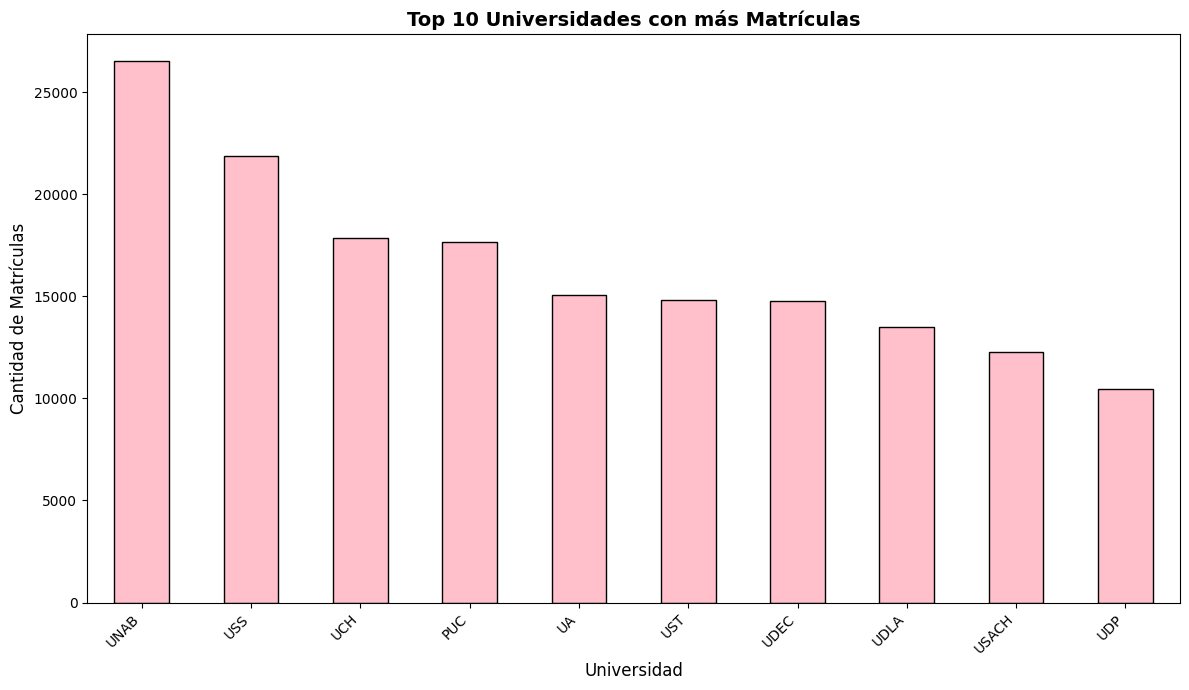

In [72]:
#VISUALIZACION DE LOS DATOS - CODIGO DE UNIVERSIDAD

# algunos nombres de las universidad segun su codigo
# (ojo que ahi preferi graficar un poco primero para ver cuales eran las del top 10)
mapa_univ = {11: "UCH", 12: "PUC", 13: "UDEC", 14: "PUCV",
    15: "USM", 16:"USACH", 17: "UACH", 18:"UCN", 19: "UV",
    38: "UDP", 41: "UNAB", 49: "UA", 50: "USS", 55: "UST", 56: "UDLA"}

dataf_matricula['NOMBRE_UNIV'] = dataf_matricula['CODIGO_UNIV'].map(mapa_univ)

top10 = dataf_matricula['NOMBRE_UNIV'].value_counts().head(10)

#definimos el tamaño del grafico y sus caracteristicas
plt.figure(figsize=(12, 7))
top10.plot(kind='bar', color='pink', edgecolor='black')

plt.title('Top 10 Universidades con más Matrículas', fontsize=14, fontweight='bold')
plt.xlabel('Universidad', fontsize=12)
plt.ylabel('Cantidad de Matrículas', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout()
plt.show() # muestra el grafico

In [56]:
#VISUALIZACION DE LOS DATOS - CODIGO (de carrera)

# uso el archivo excel para poder ver que carreras son las mas matriculadas en los 3 años
# sin importar la universidad
base_path = os.path.dirname(os.getcwd())  # Esto sube un nivel desde 'Análisis Exploratorio'

file_excel23 = os.path.join(base_path, 'DEMRE_bdd', '2023','Matricula','Matricula_Admisión2023','Libro_CódigosADM2023_ArchivoMatricula.xlsx')
file_excel24 = os.path.join(base_path, 'DEMRE_bdd', '2024','Matricula','Matricula_Admisión2024','Libro_CódigosADM2024_ArchivoMatricula.xlsx')
file_excel25 = os.path.join(base_path, 'DEMRE_bdd', '2025','Matricula','Matricula_Admisión2025','Libro_CódigosADM2025_ArchivoMatricula.xlsx')


excel_matricula_23 = pd.read_excel(file_excel23, sheet_name=1)
excel_matricula_24 = pd.read_excel(file_excel24, sheet_name=1)
excel_matricula_25 = pd.read_excel(file_excel25, sheet_name=1)

df_excel = pd.concat([excel_matricula_23, excel_matricula_24, excel_matricula_25], ignore_index=True)
df_excel.columns

top10_carreras = df_excel["CARRERA"].value_counts().head(10)
print(top10_carreras)

CARRERA
DERECHO                    66
PSICOLOGÃA                52
ENFERMERÃA                49
KINESIOLOGÃA              44
TERAPIA OCUPACIONAL        43
TRABAJO SOCIAL             40
INGENIERÃA COMERCIAL      39
ARQUITECTURA               36
NUTRICIÃ“N Y DIETÃ‰TICA    35
MEDICINA                   31
Name: count, dtype: int64


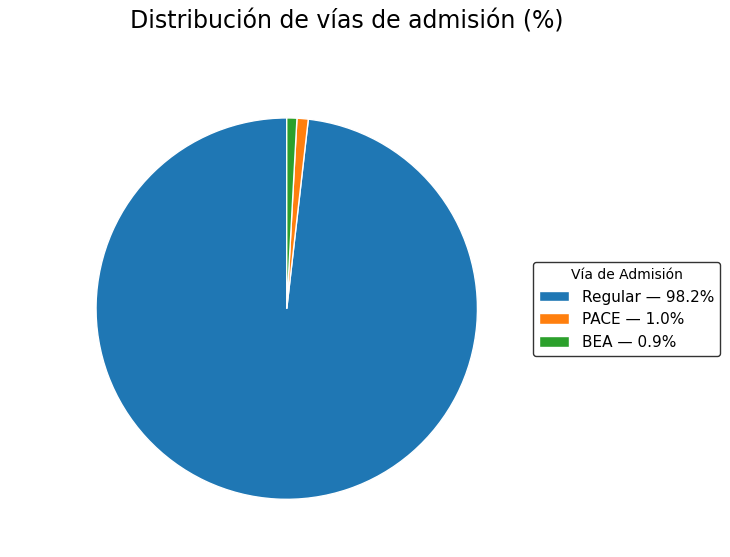

In [57]:
#VISUALIZACION DE LOS DATOS - VIA (de selección)
map_vias = {1: "Regular",
    2: "BEA",
    3: "PACE"}

dataf_matricula["VIA_NOMBRE"] = dataf_matricula["VIA"].map(map_vias)
cant_via = dataf_matricula["VIA_NOMBRE"].value_counts()

via_percent = (cant_via / cant_via.sum() * 100).round(1)  # porcentaje redondeado
# defino el tamaño del grafico
fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts = ax.pie(
    cant_via,
    labels=None,
    startangle=90,
    wedgeprops={'edgecolor': 'white'}
)
# creo un cuadro para poder entender bien los datos del grafico (sus porcentajes)
labels = [f"{name} — {pct}%" for name, pct in zip(cant_via.index, via_percent)]
plt.legend(
    wedges,
    labels,
    title="Vía de Admisión",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=11,
    frameon=True,
    facecolor='white',
    edgecolor='black'
)

plt.title("                Distribución de vías de admisión (%)", fontsize=17, pad=30)
plt.tight_layout()
plt.show()

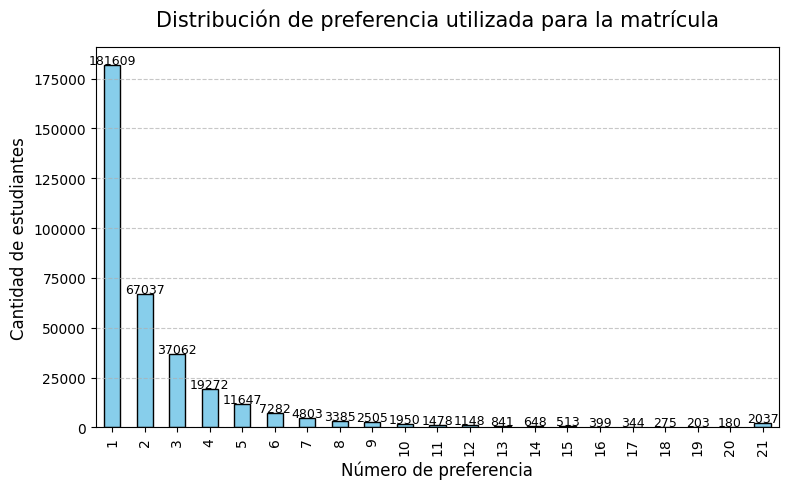

In [59]:
#VISUALIZACION DE LOS DATOS - Prefencia

dataf_matricula["PREFERENCIA"].value_counts().sort_index()
# cuento cada repeticion de cada numero de preferencia
pref_counts = dataf_matricula["PREFERENCIA"].value_counts().sort_index()
# defino el tamaño del grafico con sus caracteristicass
plt.figure(figsize=(8, 5))
pref_counts.plot(
    kind="bar",
    color="skyblue",
    edgecolor="black"
)
# defino los nombres del grafico y de los ejes
plt.title("Distribución de preferencia utilizada para la matrícula", fontsize=15, pad=15)
plt.xlabel("Número de preferencia", fontsize=12)
plt.ylabel("Cantidad de estudiantes", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
# Mostrar valores encima de cada barra
for i, v in enumerate(pref_counts):
    plt.text(i, v + 500, str(v), ha='center', fontsize=9)
# muestro el grafico
plt.tight_layout()
plt.show()

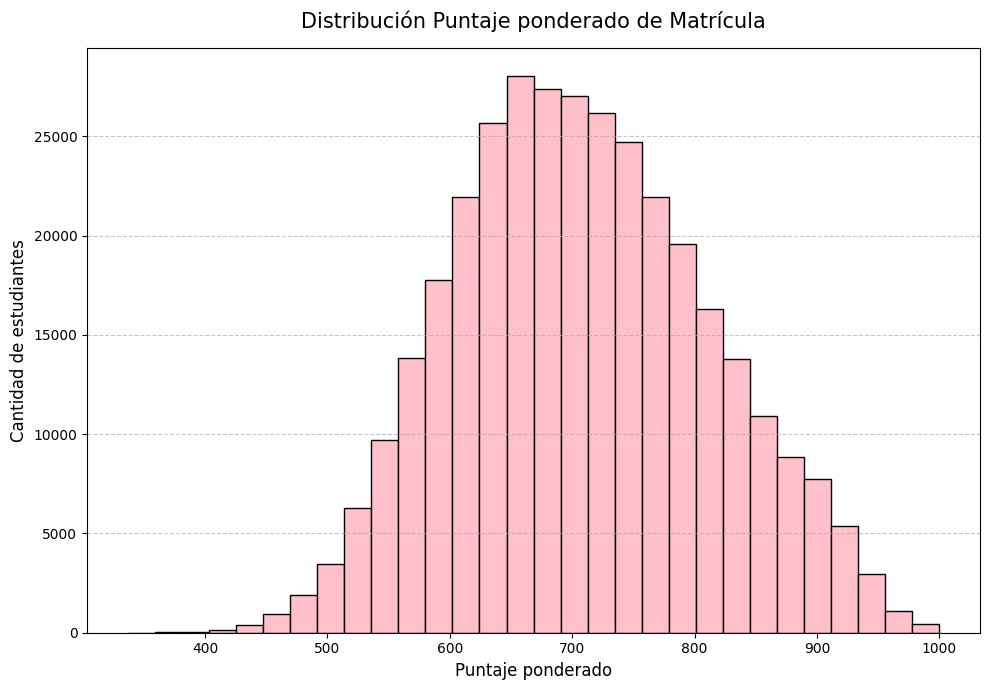

In [71]:
#VISUALIZACION DE LOS DATOS - PTJE_POND

# tomo la columna "PTJE_POND" y lo convierto en str para cambiarle la , a .
# ademas elimino los espacios que pueden haber entre los valores
# y luego lo vuelvo a convertir en float para graficar
dataf_matricula["PTJE_POND"] = (
    dataf_matricula["PTJE_POND"]
    .astype(str)
    .str.replace(",", ".")       # en caso de que los decimales usen coma
    .str.replace(" ", "")        # elimina espacios
    .astype(float))
# defino el tamaño del grafico
plt.figure(figsize=(10, 7))
plt.hist(
    dataf_matricula["PTJE_POND"],
    bins=30,
    color="pink",
    edgecolor="black"
)

# le asigno nombres al grafico y a los ejes, y muestro el grafico
plt.title("Distribución Puntaje ponderado de Matrícula", fontsize=15, pad=15)
plt.xlabel("Puntaje ponderado", fontsize=12)
plt.ylabel("Cantidad de estudiantes", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

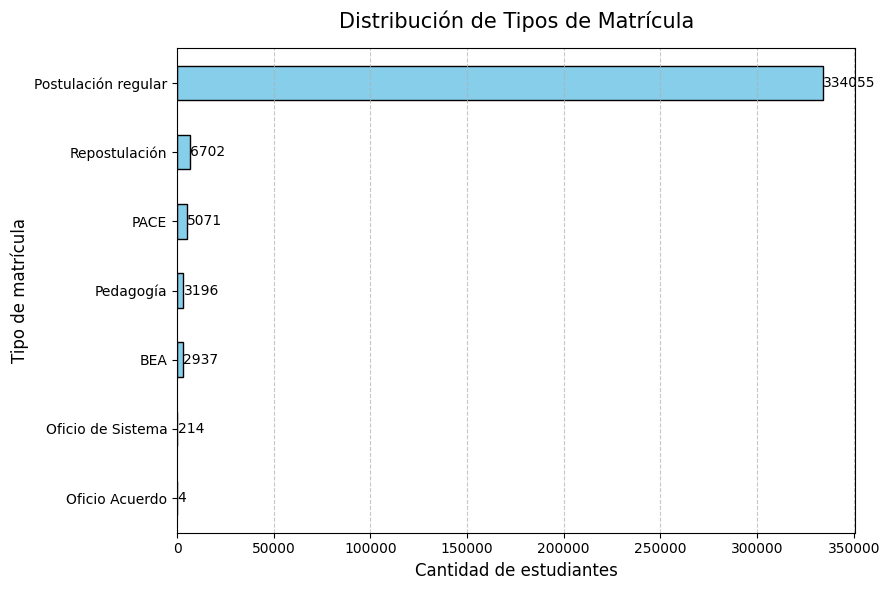

In [42]:
#VISUALIZACION DE LOS DATOS - Tipo de Matricula
# (postulación de tipo de matricula)

# creo un dict con las opciones
map_tipo_matricula = {
    1: "Postulación regular",
    2: "Repostulación",
    3: "Oficio de Sistema",
    4: "BEA",
    5: "Oficio Acuerdo",
    6: "PACE",
    8: "Pedagogía",
    9: "Pedagogía",
    10: "Pedagogía"}

# creo que una matricula con el nombre del tipo de matricula
df_matriculas_notnull["TIPO_MATRICULA_NOMBRE"] = df_matriculas_notnull["TIPO_MATRICULA"].map(map_tipo_matricula)
# agrupo 8,9,10 pq son pedagogias
tipo_counts = df_matriculas_notnull["TIPO_MATRICULA_NOMBRE"].value_counts().sort_values(ascending=True)
# defino el tamaño del grafico
plt.figure(figsize=(9, 6))
tipo_counts.plot(
    kind="barh",
    color="skyblue",
    edgecolor="black"
)
# defino los nombres de los ejes
plt.title("Distribución de Tipos de Matrícula", fontsize=15, pad=15)
plt.xlabel("Cantidad de estudiantes", fontsize=12)
plt.ylabel("Tipo de matrícula", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
for i, v in enumerate(tipo_counts):
    plt.text(v + 200, i, str(v), va='center', fontsize=10)
# muestro el grafico
plt.tight_layout()
plt.show()

------------------------------------------------------------------------------------------------------------------------